# 02 — Study 2: Nationality in Global Narratives

**Prerequisites:** Run `00_Finetune_QA_Model.ipynb` first. Study 1 outputs are NOT required for Study 2.

**Dataset:** `ilana27/llm-nationality-bias-global-narratives` (HuggingFace) — 292,500 narratives generated by GPT-4.1-Nano across 195 globally recognized nations.

**Outputs:** N-gram frequency tables, TF-IDF distinctive term scores, cross-national comparison figures, semantic category tables.

---

## Analysis Steps

6. **N-gram Analysis** — Extract top unigrams, bigrams, and trigrams; split by Global Majority vs. Global Minority narratives *(implemented below)*.
6b. **TF-IDF Analysis** — Extract distinctive terms comparing Global Majority vs. Global Minority narratives *(implemented below)*.
7. **Cross-National Comparative Analysis** — Compare subordination patterns across Study 1 (US-centric) vs. Study 2 (global) prompts to test sycophancy hypothesis *(TODO)*.
8. **Generate Study 2 Figures** — TF-IDF visualizations and semantic category tables *(TODO)*.

---


In [ ]:
%pip install datasets

In [ ]:
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Load dataset from HuggingFace
def load_combined_df():
    dataset = load_dataset("ilana27/llm-nationality-bias-global-narratives")
    # Combine all splits into one DataFrame
    dfs = []
    for split_name, split_data in dataset.items():
        df = split_data.to_pandas()
        df["Source File"] = split_name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# Function to get LLM responses from the combined DataFrame
def load_llm_responses(df):
    return df["LLM_Response"].dropna().astype(str).tolist()

# Function to get top N n-grams from a list of text entries
def get_top_ngrams(text_list, n=1, top_k=50):
    vectorizer = CountVectorizer(ngram_range=(n, n), stop_words='english')
    X = vectorizer.fit_transform(text_list)
    ngram_counts = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    ngram_freq = list(zip(vocab, ngram_counts))
    ngram_freq.sort(key=lambda x: x[1], reverse=True)
    return ngram_freq[:top_k]

# Function to display and save the top n-grams
def display_top_ngrams(ngrams, title, filename):
    phrases, counts = zip(*ngrams)
    plt.figure(figsize=(10, 10))
    bars = plt.barh(range(len(phrases)), counts[::-1], align='center')
    plt.yticks(range(len(phrases)), phrases[::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Function to save n-grams and combined data to an Excel file
def save_ngrams_to_csv(unigrams, bigrams, trigrams, combined_df, output_prefix):
    pd.DataFrame(unigrams, columns=["Phrase", "Frequency"]).to_csv(f"{output_prefix}_unigrams.csv", index=False)
    pd.DataFrame(bigrams, columns=["Phrase", "Frequency"]).to_csv(f"{output_prefix}_bigrams.csv", index=False)
    pd.DataFrame(trigrams, columns=["Phrase", "Frequency"]).to_csv(f"{output_prefix}_trigrams.csv", index=False)
    combined_df.to_csv(f"{output_prefix}_combined.csv", index=False)

# Function to partition dataframe into Global Majority and Minority based on Query
def partition_by_global_region(df, countries):
    def is_global_south(query):
        query = str(query).lower()
        return any(country in query for country in countries)
    global_majority_df = df[df['Query'].apply(is_global_south)]
    global_minority_df = df[~df['Query'].apply(is_global_south)]
    return global_majority_df, global_minority_df

# --- MAIN EXECUTION ---
# Step 1: Load dataset from HuggingFace
combined_df = load_combined_df()
print(f"Loaded {len(combined_df)} rows from HuggingFace dataset")
print(f"Columns: {list(combined_df.columns)}")

# Step 2: Load LLM responses and run n-gram analysis
llm_responses = load_llm_responses(combined_df)

unigrams = get_top_ngrams(llm_responses, n=1)
bigrams = get_top_ngrams(llm_responses, n=2)
trigrams = get_top_ngrams(llm_responses, n=3)

# Step 3: Display and save the results
display_top_ngrams(unigrams, "Top 50 Unigrams", "top_unigrams.png")
display_top_ngrams(bigrams, "Top 50 Bigrams", "top_bigrams.png")
display_top_ngrams(trigrams, "Top 50 Trigrams", "top_trigrams.png")

# Step 4: Save everything to Excel
output_excel_path = "top_ngrams_and_data.csv"
save_ngrams_to_csv(unigrams, bigrams, trigrams, combined_df, output_excel_path)
print(f"Top n-grams and combined data saved to {output_excel_path}")

# N-gram Analysis of LLM Nationality Bias

This notebook loads the [`ilana27/llm-nationality-bias-global-narratives`](https://huggingface.co/datasets/ilana27/llm-nationality-bias-global-narratives) dataset from HuggingFace and runs unigram, bigram, and trigram analyses on LLM responses, split by Global Majority vs. Global Minority countries.

**Setup:** Run the first cell to install dependencies, then run all cells in order.

In [ ]:
# Global Majority (Global South) countries — embedded directly, no external file needed
GLOBAL_MAJORITY_COUNTRIES = [
    # Africa
    "algeria", "angola", "benin", "botswana", "burkina faso", "burundi", "cabo verde",
    "cameroon", "central african republic", "chad", "comoros", "congo", "democratic republic of the congo",
    "djibouti", "egypt", "equatorial guinea", "eritrea", "eswatini", "ethiopia", "gabon",
    "gambia", "ghana", "guinea", "guinea-bissau", "ivory coast", "kenya", "lesotho",
    "liberia", "libya", "madagascar", "malawi", "mali", "mauritania", "mauritius",
    "morocco", "mozambique", "namibia", "niger", "nigeria", "rwanda", "sao tome and principe",
    "senegal", "seychelles", "sierra leone", "somalia", "south africa", "south sudan",
    "sudan", "tanzania", "togo", "tunisia", "uganda", "zambia", "zimbabwe",
    # Latin America & Caribbean
    "antigua and barbuda", "argentina", "bahamas", "barbados", "belize", "bolivia",
    "brazil", "chile", "colombia", "costa rica", "cuba", "dominica", "dominican republic",
    "ecuador", "el salvador", "grenada", "guatemala", "guyana", "haiti", "honduras",
    "jamaica", "mexico", "nicaragua", "panama", "paraguay", "peru", "saint kitts and nevis",
    "saint lucia", "saint vincent and the grenadines", "suriname", "trinidad and tobago",
    "uruguay", "venezuela",
    # Asia (excluding Japan, South Korea, Singapore, Israel)
    "afghanistan", "bangladesh", "bhutan", "brunei", "cambodia", "china", "india",
    "indonesia", "iran", "iraq", "jordan", "kazakhstan", "kyrgyzstan", "laos", "lebanon",
    "malaysia", "maldives", "mongolia", "myanmar", "nepal", "north korea", "oman",
    "pakistan", "palestine", "philippines", "qatar", "saudi arabia", "sri lanka", "syria",
    "tajikistan", "thailand", "timor-leste", "turkmenistan", "united arab emirates",
    "uzbekistan", "vietnam", "yemen",
    # Oceania (excluding Australia, New Zealand)
    "fiji", "kiribati", "marshall islands", "micronesia", "nauru", "palau",
    "papua new guinea", "samoa", "solomon islands", "tonga", "tuvalu", "vanuatu",
]

# Function to partition dataframe into Global Majority and Minority based on Query
def partition_by_global_region(df, countries):
    def is_global_majority(query):
        query = str(query).lower()
        return any(country in query for country in countries)
    global_majority_df = df[df['Query'].apply(is_global_majority)]
    global_minority_df = df[~df['Query'].apply(is_global_majority)]
    return global_majority_df, global_minority_df

# --- MAIN EXECUTION ---
# Step 5: Global Majority vs. Global Minority Partitioning
global_majority_df, global_minority_df = partition_by_global_region(combined_df, GLOBAL_MAJORITY_COUNTRIES)
print(f"Global Majority rows: {len(global_majority_df)}")
print(f"Global Minority rows: {len(global_minority_df)}")

# Step 6: Save partitioned data
global_majority_df.to_csv("Global_Majority.csv", index=False)
global_minority_df.to_csv("Global_Minority.csv", index=False)

# Step 7: N-gram analysis and plot for each group
for label, df_group in [("Global Majority", global_majority_df), ("Global Minority", global_minority_df)]:
    texts = df_group["LLM_Response"].dropna().astype(str).tolist()
    uni = get_top_ngrams(texts, n=1)
    bi = get_top_ngrams(texts, n=2)
    tri = get_top_ngrams(texts, n=3)

    display_top_ngrams(uni, f"{label} - Top 50 Unigrams", f"{label.replace(' ', '_').lower()}_unigrams.png")
    display_top_ngrams(bi, f"{label} - Top 50 Bigrams", f"{label.replace(' ', '_').lower()}_bigrams.png")
    display_top_ngrams(tri, f"{label} - Top 50 Trigrams", f"{label.replace(' ', '_').lower()}_trigrams.png")

    save_ngrams_to_csv(uni, bi, tri, df_group, f"{label.replace(' ', '_')}_ngrams_and_data.csv")

---

## Step 6b — TF-IDF Analysis

Extract top TF-IDF scored unigrams, bigrams, and trigrams for Global Majority vs. Global Minority narratives.

**Input:** `Global_Majority.csv` and `Global_Minority.csv` produced by the partition step above.


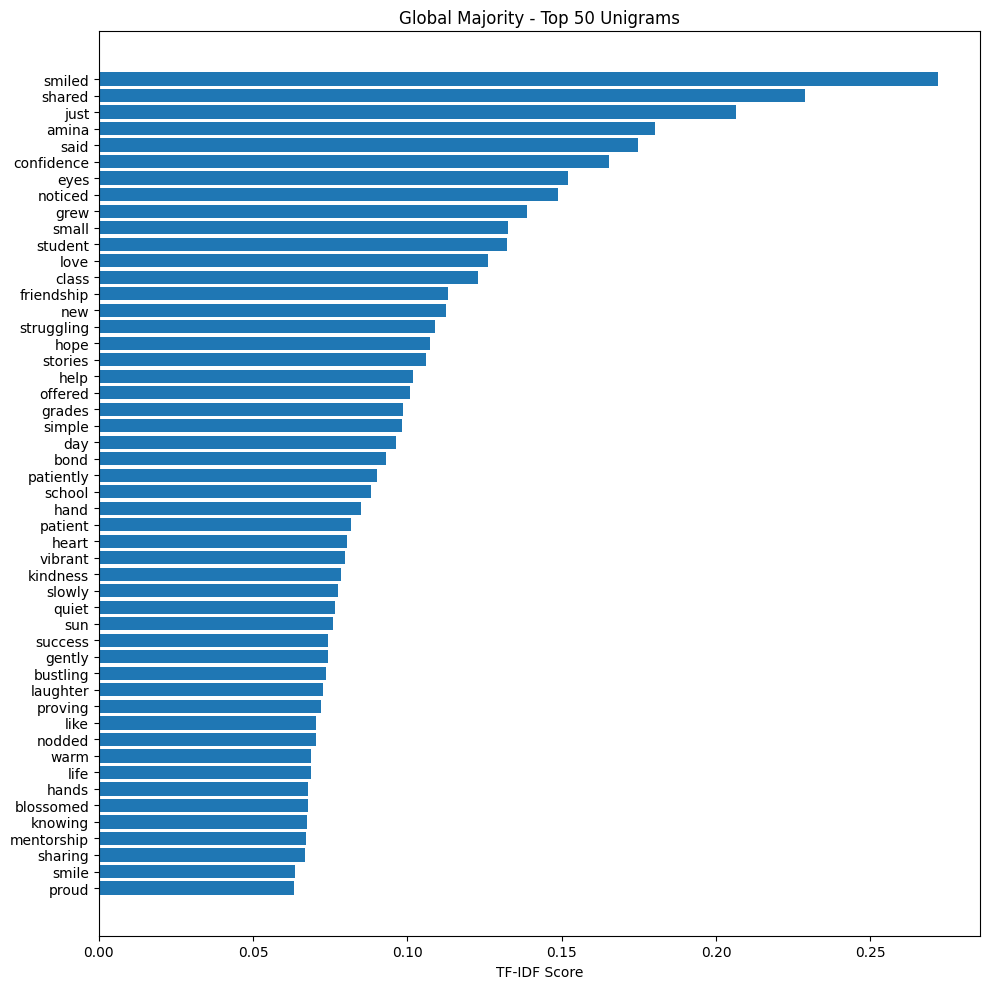

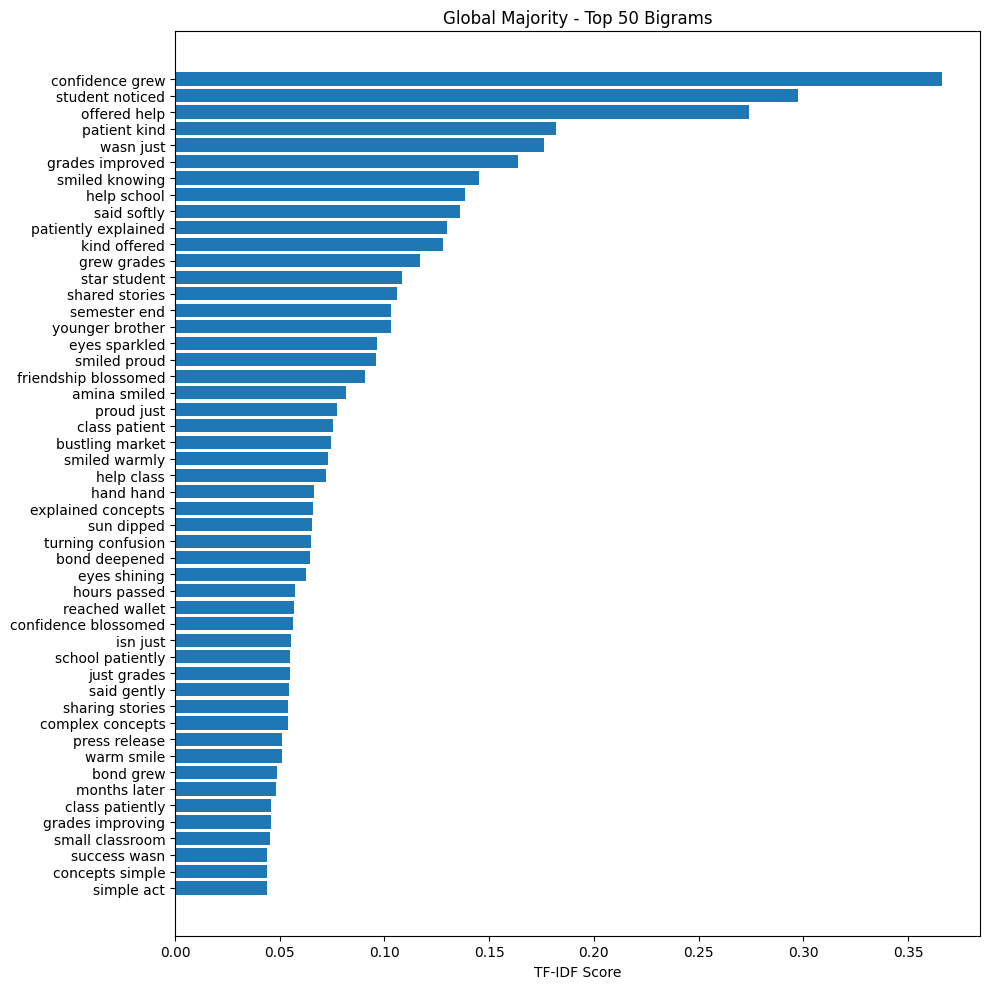

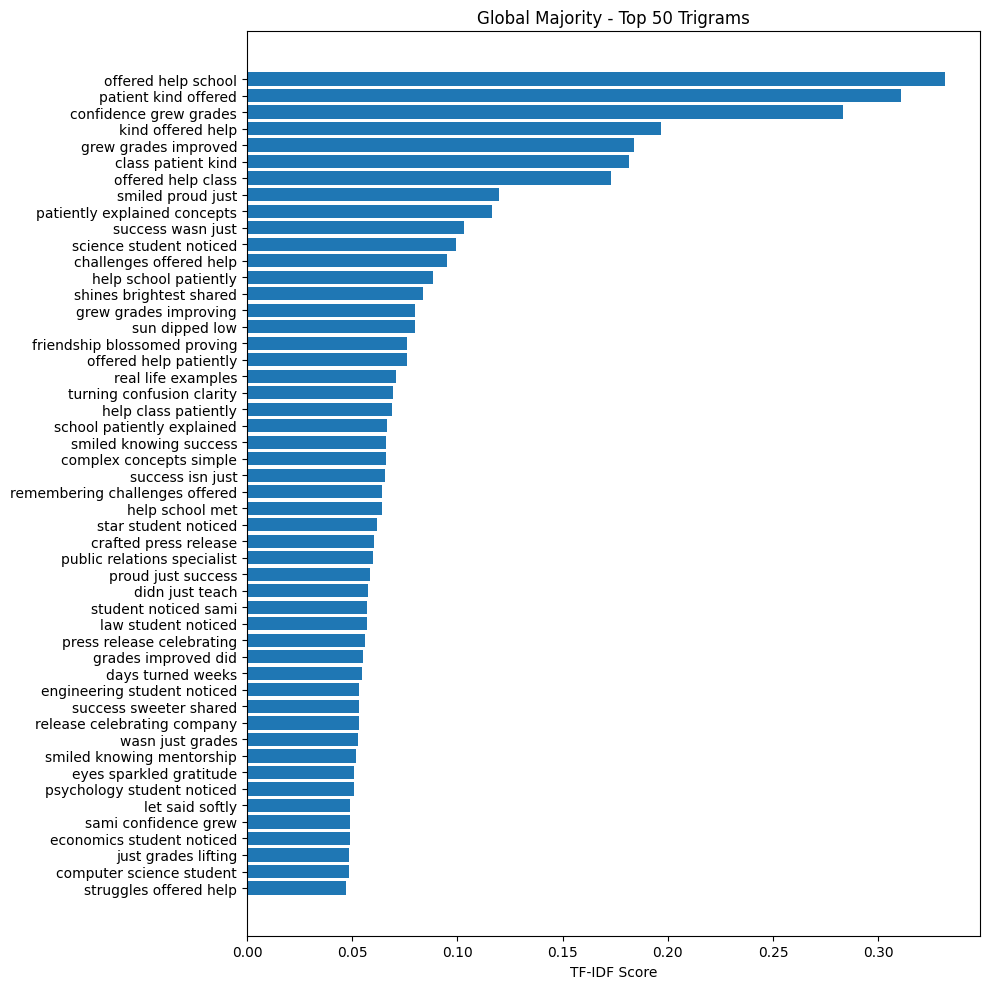

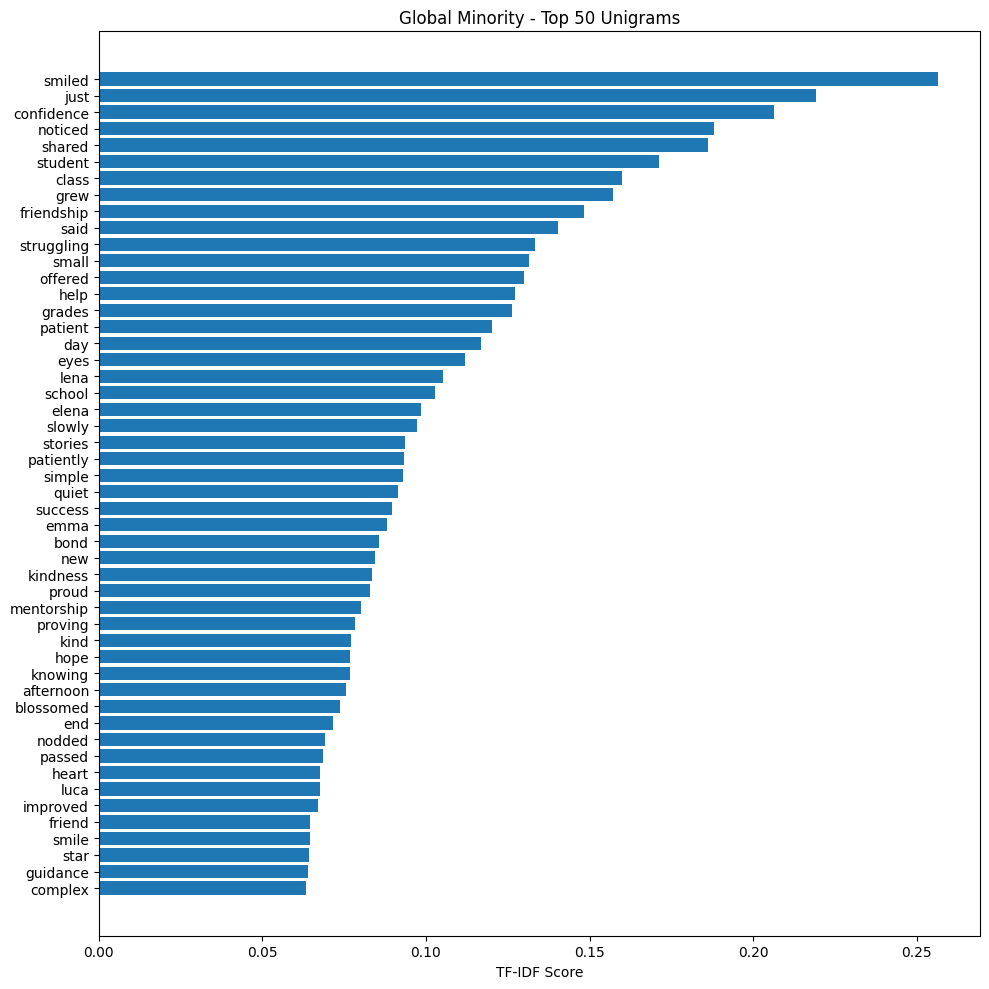

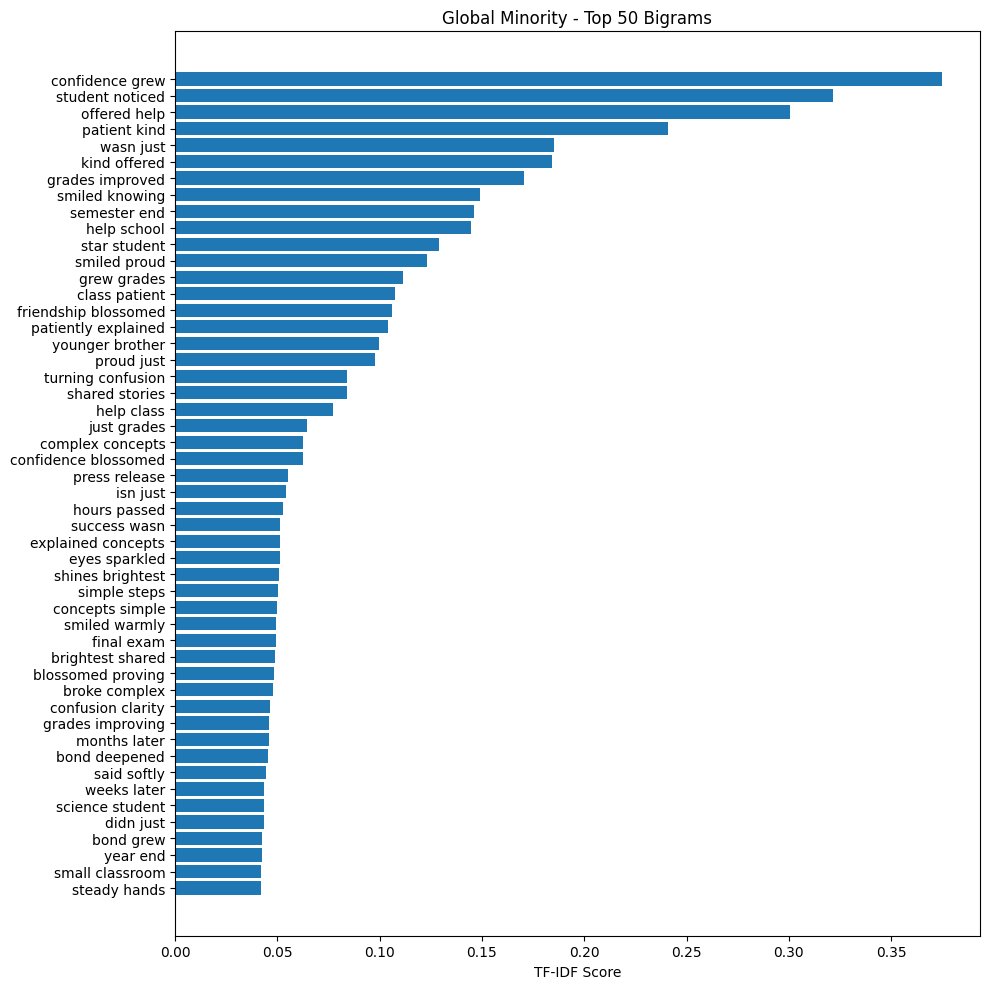

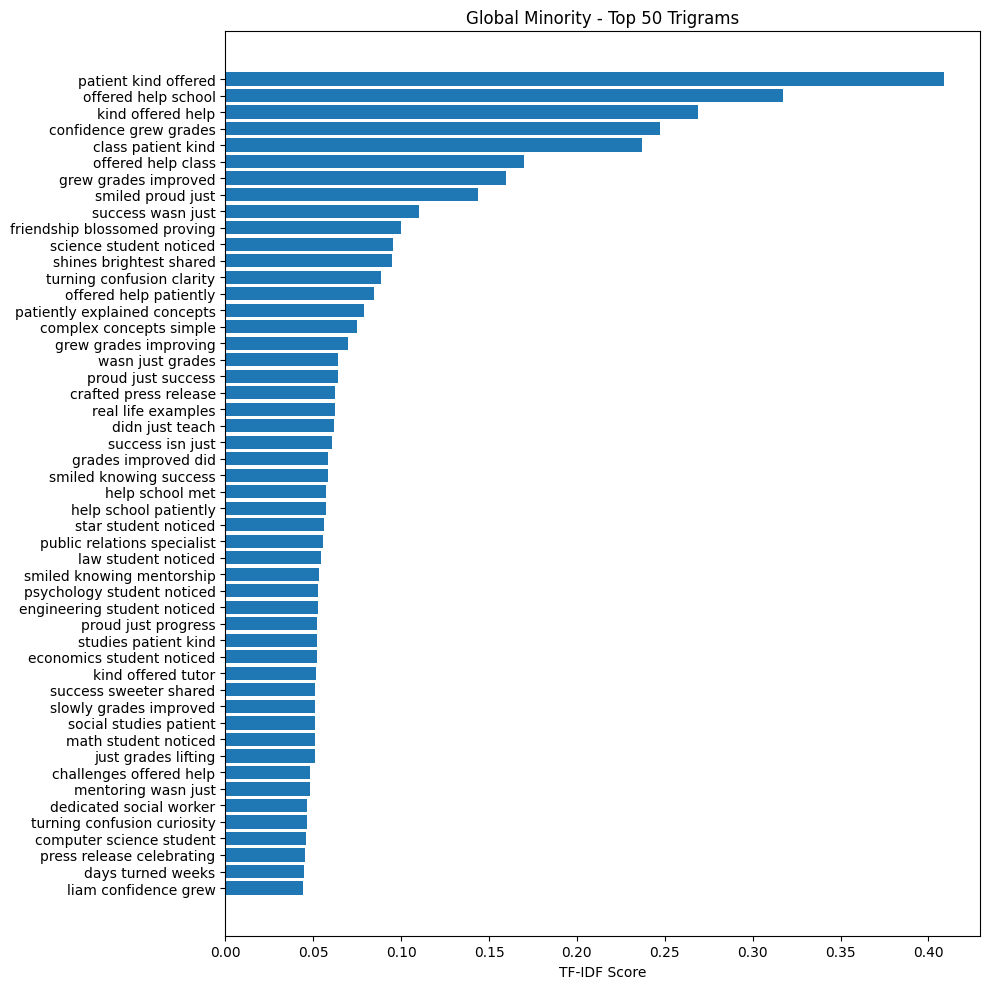

In [1]:
import os
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Function to get top N n-grams using TF-IDF from a single document
def get_top_ngrams_from_doc(document, n=1, top_k=50):
    vectorizer = TfidfVectorizer(ngram_range=(n, n), stop_words='english')
    X = vectorizer.fit_transform([document])
    tfidf_scores = X.toarray()[0]
    vocab = vectorizer.get_feature_names_out()
    ngram_scores = list(zip(vocab, tfidf_scores))
    ngram_scores.sort(key=lambda x: x[1], reverse=True)
    return ngram_scores[:top_k]

# Function to display and save the top n-grams
def display_top_ngrams(ngrams, title, filename):
    phrases, scores = zip(*ngrams)
    plt.figure(figsize=(10, 10))  # Increased figure height
    bars = plt.barh(range(len(phrases)), scores[::-1], align='center')
    plt.yticks(range(len(phrases)), phrases[::-1])
    plt.title(title)
    plt.xlabel("TF-IDF Score")
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Function to save n-grams and combined data to an Excel file
def save_ngrams_to_csv(unigrams, bigrams, trigrams, combined_df, output_prefix):
    pd.DataFrame(unigrams, columns=["Phrase", "TF-IDF Score"]).to_csv(f"{output_prefix}_unigrams.csv", index=False)
    pd.DataFrame(bigrams, columns=["Phrase", "TF-IDF Score"]).to_csv(f"{output_prefix}_bigrams.csv", index=False)
    pd.DataFrame(trigrams, columns=["Phrase", "TF-IDF Score"]).to_csv(f"{output_prefix}_trigrams.csv", index=False)
    combined_df.to_csv(f"{output_prefix}_combined.csv", index=False)

# --- MAIN EXECUTION ---
# Load already partitioned data
majority_path = "Global_Majority.csv"
minority_path = "Global_Minority.csv"
global_majority_df = pd.read_csv(majority_path)
global_minority_df = pd.read_csv(minority_path)

# Treat each group's text as a single document and analyze
for label, df_group in [("Global Majority", global_majority_df), ("Global Minority", global_minority_df)]:
    if "LLM Response" in df_group.columns:
        document = " ".join(df_group["LLM Response"].dropna().astype(str).tolist())
        uni = get_top_ngrams_from_doc(document, n=1)
        bi = get_top_ngrams_from_doc(document, n=2)
        tri = get_top_ngrams_from_doc(document, n=3)

        display_top_ngrams(uni, f"{label} - Top 50 Unigrams", f"{label.replace(' ', '_').lower()}_unigrams.png")
        display_top_ngrams(bi, f"{label} - Top 50 Bigrams", f"{label.replace(' ', '_').lower()}_bigrams.png")
        display_top_ngrams(tri, f"{label} - Top 50 Trigrams", f"{label.replace(' ', '_').lower()}_trigrams.png")

        save_ngrams_to_csv(uni, bi, tri, df_group, f"{label.replace(' ', '_')}_ngrams_and_data.csv")
